In [ ]:
import platform
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")
print(f"PyTorch version: {torch.__version__}")

NUM_WORKERS = 2


Using device: cuda
PyTorch version: 2.10.0+cu128


In [ ]:
def train_model(model, train_loader, test_loader, epochs=5, lr=0.001):
    """Train CNN and return history"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, train_accs, test_accs = [], [], []

    for epoch in range(epochs):
        # training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # show progress every 50 batches
            if (batch_idx + 1) % 50 == 0:
                batch_acc = 100. * correct / total
                print(f"  Batch [{batch_idx+1}/{len(train_loader)}] Loss: {loss.item():.4f} Acc: {batch_acc:.2f}%")

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # evaluation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_acc = 100. * correct / total
        test_accs.append(test_acc)

        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
        print(f"  Test: Acc={test_acc:.2f}%")
        print("-"*60)

    return train_losses, train_accs, test_accs


In [ ]:
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet50, ResNet50_Weights

# Define transforms for Oxford Pets (Data Augmentation)
transform_pets_train = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_pets_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

pets_train = OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform_pets_train)
pets_test = OxfordIIITPet(root='./data', split='test', download=True, transform=transform_pets_test)

pets_train_loader = DataLoader(pets_train, batch_size=32, shuffle=True, num_workers=NUM_WORKERS)
pets_test_loader = DataLoader(pets_test, batch_size=32, shuffle=False, num_workers=NUM_WORKERS)

print(f"Training samples: {len(pets_train)}")
print(f"Test samples: {len(pets_test)}")
print(f"Number of breeds: 37 (25 dogs + 12 cats)")
print(f"Image size: 224x224 (ResNet requirement)")

100%|██████████| 792M/792M [00:28<00:00, 27.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.3MB/s]


Training samples: 3680
Test samples: 3669
Number of breeds: 37 (25 dogs + 12 cats)
Image size: 224x224 (ResNet requirement)


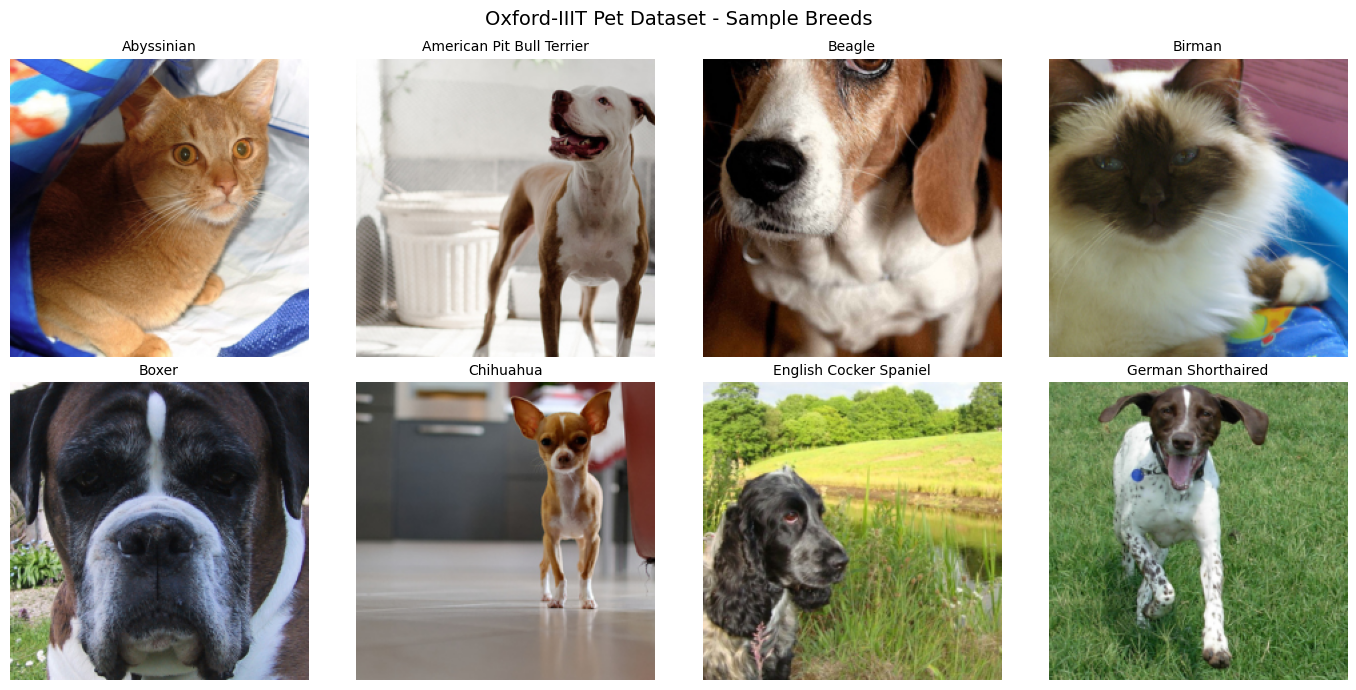

In [ ]:
# Visualize some pet images
pets_display = OxfordIIITPet(root='./data', split='trainval', download=False,
                             transform=transforms.Compose([
                                 transforms.Resize(256),
                                 transforms.CenterCrop(224),
                                 transforms.ToTensor()
                             ]))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Oxford-IIIT Pet Dataset - Sample Breeds", fontsize=14, y=0.98)

for i, ax in enumerate(axes.flat):
    img, label = pets_display[i * 100]
    ax.imshow(img.permute(1, 2, 0))
    breed_name = pets_display.classes[label].replace('_', ' ').title()
    ax.set_title(f"{breed_name}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# load pre-trained ResNet50
print("Loading pre-trained ResNet50...")
resnet_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

print("\nResNet50 loaded!")
print(f"Pre-trained on: ImageNet (1.2M images, 1000 classes)")
print(f"Architecture: 50 layers with residual connections")

# freeze ALL layers
for param in resnet_model.parameters():
    param.requires_grad = False

print("\nFroze all layers")

# replace final FC layer
# ResNet50 has 2048 features before final FC
resnet_model.fc = nn.Linear(2048, 37)  # 37 pet breeds

resnet_model = resnet_model.to(device)

# count parameters
total_params = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)

print(f"\nResNet50 Transfer Learning:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} (only final FC)")
print(f"Frozen parameters: {total_params - trainable_params:,}")
print(f"\nReady to train on Oxford Pets!")

Loading pre-trained ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 118MB/s]



ResNet50 loaded!
Pre-trained on: ImageNet (1.2M images, 1000 classes)
Architecture: 50 layers with residual connections

Froze all layers

ResNet50 Transfer Learning:
Total parameters: 23,583,845
Trainable parameters: 75,813 (only final FC)
Frozen parameters: 23,508,032

Ready to train on Oxford Pets!


In [ ]:
# train ResNet50 (only final layer)
print("Training ResNet50 Transfer Learning on Oxford Pets (20 epochs)...")
print("(Only training final FC layer - all other layers frozen)")

# use same train_model function from Part 1
resnet_train_losses, resnet_train_accs, resnet_test_accs = train_model(
    resnet_model, pets_train_loader, pets_test_loader, epochs=20, lr=0.001
)

print(f"\nTraining complete!")
print(f"Final Train Accuracy: {resnet_train_accs[-1]:.2f}%")
print(f"Final Test Accuracy: {resnet_test_accs[-1]:.2f}%")
print(f"\nNote: Training only final layer is MUCH faster than training from scratch!")

Training ResNet50 Transfer Learning on Oxford Pets (20 epochs)...
(Only training final FC layer - all other layers frozen)
  Batch [50/115] Loss: 2.0162 Acc: 46.69%
  Batch [100/115] Loss: 1.2472 Acc: 64.41%

Epoch [1/20]
  Train: Loss=1.9188, Acc=66.66%
  Test: Acc=85.25%
------------------------------------------------------------
  Batch [50/115] Loss: 0.8156 Acc: 89.56%
  Batch [100/115] Loss: 0.5394 Acc: 90.12%

Epoch [2/20]
  Train: Loss=0.6572, Acc=90.46%
  Test: Acc=87.63%
------------------------------------------------------------
  Batch [50/115] Loss: 0.3623 Acc: 93.50%
  Batch [100/115] Loss: 0.3828 Acc: 92.91%

Epoch [3/20]
  Train: Loss=0.4230, Acc=92.80%
  Test: Acc=89.18%
------------------------------------------------------------
  Batch [50/115] Loss: 0.2794 Acc: 95.25%
  Batch [100/115] Loss: 0.2839 Acc: 94.69%

Epoch [4/20]
  Train: Loss=0.3164, Acc=94.54%
  Test: Acc=90.05%
------------------------------------------------------------
  Batch [50/115] Loss: 0.2318

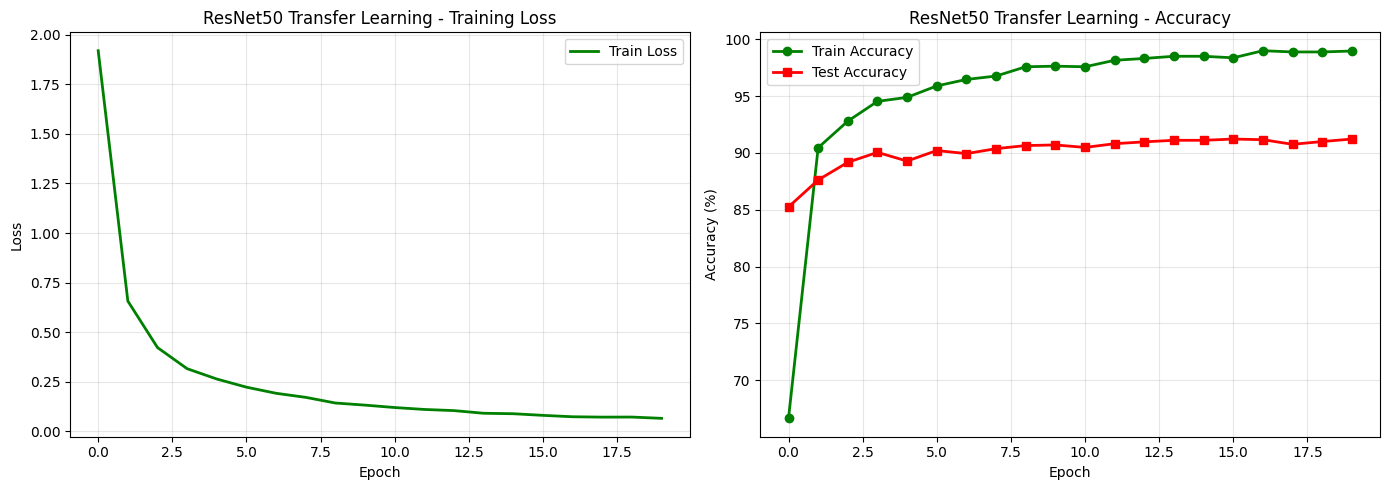

TRANSFER LEARNING RESULTS
ResNet50 (Transfer Learning): 91.22%

Task: Classify 37 pet breeds
Training time: ~5 minutes (20 epochs)
Parameters trained: 75,813 (only final layer)


In [ ]:
# plot ResNet50 training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(resnet_train_losses, 'g-', linewidth=2, label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('ResNet50 Transfer Learning - Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(resnet_train_accs, 'g-', linewidth=2, label='Train Accuracy', marker='o')
ax2.plot(resnet_test_accs, 'r-', linewidth=2, label='Test Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('ResNet50 Transfer Learning - Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("TRANSFER LEARNING RESULTS")
print(f"ResNet50 (Transfer Learning): {resnet_test_accs[-1]:.2f}%")
print(f"\nTask: Classify 37 pet breeds")
print(f"Training time: ~5 minutes (20 epochs)")
print(f"Parameters trained: {trainable_params:,} (only final layer)")

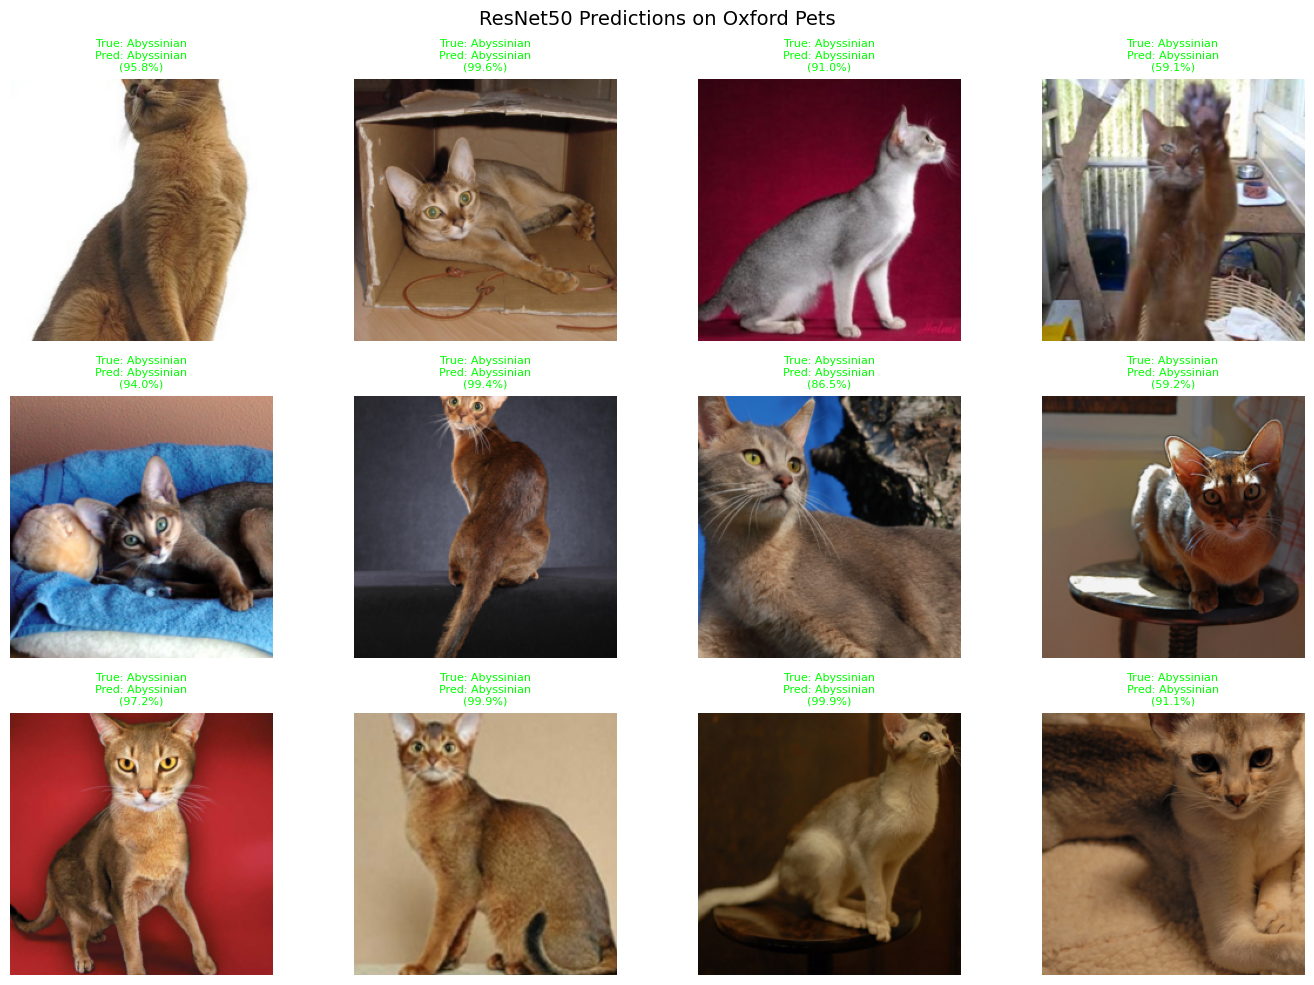


Batch Accuracy: 96.9%
Correct: 31/32

ResNet50 successfully classifies pet breeds!


In [ ]:
# visualize ResNet50 predictions on pet breeds
resnet_model.eval()

# get a batch of test images
dataiter = iter(pets_test_loader)
next(dataiter)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = resnet_model(images)
    _, predicted = outputs.max(1)
    probabilities = torch.softmax(outputs, dim=1)

# denormalize images for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
images_denorm = images * std + mean

# plot predictions
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle("ResNet50 Predictions on Oxford Pets", fontsize=14, y=0.98)

for idx, ax in enumerate(axes.flat):
    img = images_denorm[idx].cpu().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    true_label = pets_test.classes[labels[idx]].replace('_', ' ').title()
    pred_label = pets_test.classes[predicted[idx]].replace('_', ' ').title()
    confidence = probabilities[idx][predicted[idx]].item() * 100

    ax.imshow(img)

    # color: green if correct, red if wrong
    color = 'lime' if predicted[idx] == labels[idx] else 'red'
    title = f"True: {true_label}\nPred: {pred_label}\n({confidence:.1f}%)"
    ax.set_title(title, fontsize=8, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

batch_acc = (predicted == labels).sum().item() / len(labels) * 100
print(f"\nBatch Accuracy: {batch_acc:.1f}%")
print(f"Correct: {(predicted == labels).sum().item()}/{len(labels)}")
print(f"\nResNet50 successfully classifies pet breeds!")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

from tensorflow.keras.applications import DenseNet121
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout,MaxPooling2D , Conv2D,Flatten
from tensorflow.keras.models import Sequential

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import classification_report


from IPython.display import clear_output
import warnings

warnings.filterwarnings('ignore')
SEED = 12
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 64
EPOCHS = 1
LR =  0.00003

In [ ]:
INPUT_SHAPE=(IMG_HEIGHT,IMG_WIDTH,3)

def transfer_learning():
    base_model=DenseNet121(include_top=False,input_shape=INPUT_SHAPE,weights="imagenet")
    print(len(base_model.layers))
    thr=149
    for layers in base_model.layers[:thr]:
        layers.trainable=False

    for layers in base_model.layers[thr:]:
        layers.trainable=True

    return base_model

In [ ]:
transfer_learning()

427


<Functional name=densenet121, built=True>